# TLDR:
* Model: Davit
* PreProcessing: None
* Data: DE features
* Validation: Subject-Independent LOSO (Leave-One-Subject-Out)
* Balancing Technique: Weighted class loss
* Labels: 0 (Neutral) , 1  Negative (Sad), 2  (Fear) , 3 Positive (Happy)

In [1]:
!pip install --no-deps torcheeg -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.4/251.4 kB 11.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
!pip install spectrum lmdb mne_connectivity xmltodict wfdb -q
!git clone https://github.com/jiaowoguanren0615/DaViT-Pytorch DaViT

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.4/233.4 kB 9.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 113.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torcheeg 1.1.3 requires scipy<=1.10.1,>=1.7.3, but you have scipy 1.16.3 which is incompatible.
Cloning into 'DaViT'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing 

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torcheeg import transforms
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torcheeg.datasets import SEEDIVFeatureDataset
from DaViT.models.davit import DaViT

from torchvision.transforms import RandomErasing
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import time
import os
import shutil
import random
import math

import numpy as np

from torcheeg.datasets.constants import SEED_IV_CHANNEL_LOCATION_DICT

# --- THE MAIN SUBJECT LOOP ---
import numpy as np
import matplotlib.pyplot as plt


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [4]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(42)

In [5]:
# used for logging
TRIAL_NUMBER = 64

In [6]:
USE_GPU = 1
BATCH_SIZE = 64
DROPOUT = 0.5
ATTN_DROPOUT = 0.5
LR = 5e-4
WEIGHT_DECAY = 2e-1
EPOCHS_COUNT = 250
EARLY_STOP = 1
patience = 25

In [7]:
# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() and USE_GPU else "cpu")
print(f"device: {device}")


device: cuda


In [8]:
two_no_neutral = {
    0: "UNREACHABLE",  # Neutral
    1: 0,  # Sad
    2: 0,  # Fear
    3: 1,  # Happy
}

two_with_neutral = {
    0: 0,  # Neutral
    1: 0,  # Sad
    2: 0,  # Fear
    3: 1,  # Happy
}

three = {
    0: 0,  # Neutral
    1: 1,  # Sad
    2: 1,  # Fear
    3: 2,  # Happy
}

four = {
    0: 0,  # Neutral
    1: 1,  # Sad
    2: 2,  # Fear
    3: 3,  # Happy
}

In [9]:
emotions_table = two_no_neutral


In [10]:
class RemapLabel:
    def __call__(self, y):
        return {"y": emotions_table[y]}


In [11]:
io_path = f"./tmp_out/seed_iv_feautres_{TRIAL_NUMBER}"
if os.path.exists(io_path):
    shutil.rmtree(io_path)
root_path = "/kaggle/input/datasets/phhasian0710/seed-iv/eeg_feature_smooth"

# io_path = "./tmp_out/seed_iv_features"
# root_path = "/kaggle/input/seed-iv/eeg_feature_smooth"

In [12]:
# 3. Load Data

dataset = SEEDIVFeatureDataset(
    io_path=io_path,
    root_path=root_path,
    feature=["de_LDS"],
    offline_transform=transforms.Compose(
        [
            # transforms.PickElectrode(target_indices),
            # transforms.BaselineRemoval(),
            transforms.To2d(),
            transforms.MeanStdNormalize(axis=(1, 2)),
            transforms.ToTensor()
        ]
    ),
    label_transform=transforms.Compose(
        [
            transforms.Select("emotion"),
            RemapLabel(),
        ]
    ),
    io_mode="memory",
)


[2026-07-05 14:26:10] INFO (torcheeg/MainThread) 🔍 | Processing EEG data. Processed EEG data has been cached to ./tmp_out/seed_iv_feautres_64.
[2026-07-05 14:26:10] INFO (torcheeg/MainThread) ⏳ | Monitoring the detailed processing of a record for debugging. The processing of other records will only be reported in percentage to keep it clean.
[PROCESS]:   0%|          | 0/45 [00:00<?, ?it/s]
[RECORD /kaggle/input/datasets/phhasian0710/seed-iv/eeg_feature_smooth/1/4_20151111.mat]: 0it [00:00, ?it/s]
[RECORD /kaggle/input/datasets/phhasian0710/seed-iv/eeg_feature_smooth/1/4_20151111.mat]: 1it [00:00,  3.91it/s]
[RECORD /kaggle/input/datasets/phhasian0710/seed-iv/eeg_feature_smooth/1/4_20151111.mat]: 517it [00:00, 1849.55it/s]
[PROCESS]: 100%|██████████| 45/45 [00:14<00:00,  3.17it/s]


In [13]:
counts = dataset.info["emotion"].value_counts().sort_index()
total = len(dataset.info)

In [14]:
if emotions_table == two_no_neutral:
    print(f"Total Segments (before droping 0): {total}")
    print("Count per Emotion:")
    print(counts)
    print("-" * 30)

Total Segments (before droping 0): 37575
Count per Emotion:
emotion
0    10170
1    10245
2     9225
3     7935
Name: count, dtype: int64
------------------------------


In [15]:
# 1. Get the metadata DataFrame
df = dataset.info
if emotions_table == two_no_neutral:
    df = df[df["emotion"] != 0]
# df = dataset.info.groupby(
#     ["subject_id", "session_id", "trial_id"], group_keys=False
# ).apply(lambda x: x.iloc[:30])


In [16]:
# 2. Count the segments for each emotion
# 0: (Sad, Fear), 1: Happy
counts = df["emotion"].value_counts().sort_index()
total = len(df)

print(f"Total Segments: {total}")
print("-" * 30)
print("Count per Emotion:")
print(counts)

print("-" * 30)
print("Percentage per Emotion:")
percentages = (counts / total) * 100
print(percentages.round(2))

# 3. Check for Imbalance
# If the difference between max and min is > 10%, we might need a WeightedSampler
max_pct = percentages.max()
min_pct = percentages.min()

if (max_pct - min_pct) > 10:
    print(f"\n⚠️ WARNING: Data is IMBALANCED (Diff: {max_pct - min_pct:.2f}%)")
    print("Consider using a WeightedRandomSampler.")
else:
    print(f"\n✅ Data is reasonably BALANCED (Diff: {max_pct - min_pct:.2f}%)")

Total Segments: 27405
------------------------------
Count per Emotion:
emotion
1    10245
2     9225
3     7935
Name: count, dtype: int64
------------------------------
Percentage per Emotion:
emotion
1    37.38
2    33.66
3    28.95
Name: count, dtype: float64

✅ Data is reasonably BALANCED (Diff: 8.43%)


In [17]:
# 4. Check Data Shape & Setup Model
# We fetch one sample to determine input channels and dimensions
# (using the whole dataset for detection is fine as shape is consistent)
temp_loader = DataLoader(dataset, batch_size=1, shuffle=False)
temp_X, _ = next(iter(temp_loader))
input_channels = temp_X.shape[1]
print(f"Detected Input Shape: {temp_X.shape}")
print(f"Setting model in_chans to: {input_channels}")


Detected Input Shape: torch.Size([1, 1, 62, 5])
Setting model in_chans to: 1


In [18]:
def DaViT_eeg(
    pretrained=False, pretrained_cfg=None, pretrained_cfg_overlay=None, **kwargs
):
    model_kwargs = dict(
        patch_size=4,
        in_chans=input_channels,
        window_size=3,
        # Restoring "Tiny" dimensions (User has VRAM headroom)
        # embed_dims=(96, 192, 384, 768),
        # num_heads=(3, 6, 12, 24),
        # embed_dims=(64, 128, 256, 512),
        # num_heads=(2, 4, 8, 16),
        # embed_dims=(48, 96, 192, 384),
        # num_heads=(2, 3, 8, 16),
        embed_dims=(32, 64, 128, 256),
        num_heads=(1, 2, 4, 8),
        depths=(1, 1, 2, 1),
        mlp_ratio=2.0,
        overlapped_patch=False,
        num_classes=kwargs.get("_num_classes", 4),
        drop_rate=kwargs.get("dropout", 0.5),
        attn_drop_rate=kwargs.get("attn_dropout", 0.5),
        drop_path_rate=0.3,  # Add Stochastic Depth
        **kwargs,
    )

    return DaViT(**model_kwargs)


In [19]:
subjects = sorted(df["subject_id"].unique())  # Get list of all 15 subjects
print(f"Total subjects: {len(subjects)}")
print(f"Subjects: {subjects}")
print("Validation Strategy: Leave-One-Subject-Out (LOSO)")


Total subjects: 15
Subjects: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
Validation Strategy: Leave-One-Subject-Out (LOSO)


In [20]:
# --- MIXUP HELPER FUNCTIONS ---
def mixup_data(x, y, alpha=1.0):
    """
    Applies Mixup augmentation to a batch of data.

    Logic:
    1. Generate a mixing coefficient (lambda) from a Beta(alpha, alpha) distribution.
       - If alpha is close to 0, lambda is close to 0 or 1 (little mixing).
       - If alpha is large, lambda is close to 0.5 (strong mixing).
    2. Shuffle the batch indices to get a "partner" for every sample.
    3. Create a new "mixed" input: mixed_x = lambda * x + (1 - lambda) * x[shuffled_indices]

    Returns:
        mixed_x: The blended input tensor.
        y_a: The original labels.
        y_b: The labels of the shuffled samples.
        lam: The mixing coefficient used.
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """
    Calculates the Mixup loss.

    Since the input was a mix of two samples (A and B) with weight lambda:
    Loss = lambda * Loss(pred, Label_A) + (1 - lambda) * Loss(pred, Label_B)
    """
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


In [21]:
train_transforms = transforms.Compose(
    [
        transforms.RandomMask(p=0.1),
        transforms.RandomNoise(p=0.2),
    ]
)

In [22]:
all_targets = []
all_predictions = []

In [23]:
# --- LOSO (Leave-One-Subject-Out) Cross-Validation ---
# For each fold, one subject is held out as the TEST set,
# and ALL remaining subjects are used for TRAINING.
# This evaluates subject-independent generalization.

all_subject_accuracies = []
all_subject_histories = {}
for test_subject_id in subjects:
    print("\n========================================")
    print(f"  LOSO FOLD: Testing on Subject {test_subject_id}")
    print(f"  Training on {len(subjects) - 1} other subjects")
    print("========================================")

    # 1. Split data: test = held-out subject, train = all other subjects
    test_df = df[df["subject_id"] == test_subject_id]
    train_df = df[df["subject_id"] != test_subject_id]

    test_indices = test_df.index.tolist()
    train_indices = train_df.index.tolist()

    print(f"Train samples: {len(train_indices)} | Test samples: {len(test_indices)}")

    train_set = Subset(dataset, train_indices)
    test_set = Subset(dataset, test_indices)

    # 2. Compute class weights from training set
    raw_labels = dataset.info.iloc[train_indices]["emotion"].values
    mapped_labels = [emotions_table[y] for y in raw_labels]
    # mapped_labels = raw_labels

    class_counts = np.bincount(mapped_labels)
    print(f"class_counts: {class_counts}")
    classes_ = np.unique(mapped_labels)
    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=classes_,
        y=mapped_labels,
    )
    print(f"class_weights: {class_weights}")

    # 3. Loaders
    train_loader = DataLoader(
        train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
    )
    test_loader = DataLoader(
        test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    )
    train_count = len(train_loader)
    test_count = len(test_loader)

    # 4. FRESH Model & Optimizer (Reset for every fold)
    model = DaViT_eeg(
        dropout=DROPOUT, attn_dropout=ATTN_DROPOUT, _num_classes=len(class_weights)
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    # OneCycleLR: Warmup + Cosine Annealing
    scheduler = OneCycleLR(
        optimizer,
        max_lr=LR,
        epochs=EPOCHS_COUNT,
        steps_per_epoch=len(train_loader),
        pct_start=0.3,  # 30% warmup
        div_factor=10,
        final_div_factor=1000,
    )
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(class_weights).to(device).float(), label_smoothing=0.1
    )

    # 5. Training Loop for this fold
    best_acc = 0.0
    best_tacc = 0.0
    best_loss = float("inf")
    counter = 0

    subject_train_acc = []
    subject_val_acc = []
    prinT = 1

    for epoch in range(EPOCHS_COUNT):
        startTime = time.time()
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for batch in train_loader:
            X, y = batch
            # Augmentation: Random Erasing
            X = train_transforms(eeg=X)["eeg"]

            if prinT:
                print(f"X: {X.shape},y: {y.shape}")
                prinT = 0

            X = X.to(device)
            y = y.to(device).long()

            # 2. Apply Mixup
            X, y_a, y_b, lam = mixup_data(X, y, alpha=0.2)
            X, y_a, y_b = map(torch.autograd.Variable, (X, y_a, y_b))

            optimizer.zero_grad()
            outputs = model(X)

            # 3. Use Mixup Loss
            loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
            loss.backward()
            optimizer.step()

            # For accuracy, we just compare against the dominant label (or y_a)
            # Mixup creates "soft" accuracy, but standard accuracy is fine for logging
            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (
                lam * predicted.eq(y_a.data).cpu().sum().float()
                + (1 - lam) * predicted.eq(y_b.data).cpu().sum().float()
            ).item()
            # scheduler step for OneCycleLR is per batch
            scheduler.step()
            train_loss += loss.item()

        train_acc = (correct / total) * 100
        avg_train_loss = train_loss / train_count

        # Validation (on held-out subject)
        model.eval()
        val_correct = 0
        val_total = 0
        val_loss = 0
        with torch.no_grad():
            for batch in test_loader:
                X, y = batch

                X = X.to(device)
                y = y.to(device).long()

                output = model(X)

                loss = criterion(output, y)
                val_loss += loss.item()
                _, predicted = torch.max(output.data, 1)
                val_total += y.size(0)
                val_correct += (predicted == y).sum().item()
                all_targets.append(y)
                all_predictions.append(predicted)

        val_acc = 100 * val_correct / val_total
        avg_val_loss = val_loss / test_count
        current_lr = optimizer.param_groups[0]["lr"]
        elabsedTime = time.time() - startTime
        loss_ratio = avg_train_loss / avg_val_loss
        subject_train_acc.append(train_acc)
        subject_val_acc.append(val_acc)

        # Early Stopping check (Monitor Validation Accuracy)
        is_best_acc = False
        if (val_acc > best_acc) or (
            (best_acc - val_acc) <= 0.5 and train_acc >= best_tacc
        ):
            is_best_acc = True
            best_acc = val_acc
            best_tacc = train_acc
            best_loss = avg_val_loss
            counter = 0
        else:
            counter += 1
            if EARLY_STOP and counter >= patience:
                break

        print(
            f"Epoch {epoch + 1}: Train Acc={train_acc:.2f}% | Test Acc (Subject {test_subject_id})={val_acc:.2f}% | Loss: {avg_train_loss:.4f}/{avg_val_loss:.4f} | Loss Ratio: {loss_ratio:.2f} | LR: {current_lr:.6f} | Time: {elabsedTime:.2f}s {'[BEST]' if is_best_acc else ''}"
        )

    all_subject_accuracies.append(best_acc)
    all_subject_histories[test_subject_id] = {
        "train": subject_train_acc,
        "val": subject_val_acc,
    }
    print(f"\n  => Subject {test_subject_id} Best Test Acc: {best_acc:.2f}%")


  LOSO FOLD: Testing on Subject 1
  Training on 14 other subjects
Train samples: 25578 | Test samples: 1827
class_counts: [18172  7406]
class_weights: [0.70377504 1.7268431 ]
X: torch.Size([64, 1, 62, 5]),y: torch.Size([64])
Epoch 1: Train Acc=58.38% | Test Acc (Subject 1)=70.44% | Loss: 0.6775/0.6986 | Loss Ratio: 0.97 | LR: 0.000050 | Time: 18.62s [BEST]
Epoch 2: Train Acc=68.54% | Test Acc (Subject 1)=77.45% | Loss: 0.6142/0.6295 | Loss Ratio: 0.98 | LR: 0.000051 | Time: 15.34s [BEST]
Epoch 3: Train Acc=73.18% | Test Acc (Subject 1)=75.64% | Loss: 0.5717/0.6108 | Loss Ratio: 0.94 | LR: 0.000052 | Time: 15.53s 
Epoch 4: Train Acc=75.96% | Test Acc (Subject 1)=79.09% | Loss: 0.5409/0.6158 | Loss Ratio: 0.88 | LR: 0.000053 | Time: 15.41s [BEST]
Epoch 5: Train Acc=78.02% | Test Acc (Subject 1)=80.57% | Loss: 0.5222/0.6190 | Loss Ratio: 0.84 | LR: 0.000055 | Time: 15.28s [BEST]
Epoch 6: Train Acc=77.75% | Test Acc (Subject 1)=77.23% | Loss: 0.5146/0.6461 | Loss Ratio: 0.80 | LR: 0.00005

In [24]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

2.10.0+cu128
12.8
Tesla T4


In [25]:
# --- FINAL RESULTS ---
avg_acc = sum(all_subject_accuracies) / len(all_subject_accuracies)
print("\n========================================")
print(f"FINAL LOSO AVERAGE ACCURACY: {avg_acc:.2f}%")
print(f"Per-Subject Test Accuracies: {all_subject_accuracies}")
print(f"Std Dev: {np.std(all_subject_accuracies):.2f}%")
print("========================================")



FINAL LOSO AVERAGE ACCURACY: 83.26%
Per-Subject Test Accuracies: [84.89326765188834, 61.74055829228243, 83.41543513957308, 91.18773946360153, 82.2112753147236, 85.27640941434045, 95.01915708812261, 86.31636562671045, 87.9584017515052, 92.61083743842364, 80.84291187739464, 82.43021346469622, 50.02736726874658, 89.9288451012589, 95.07389162561576]
Std Dev: 11.79%


Saved subject_accuracies 64.png


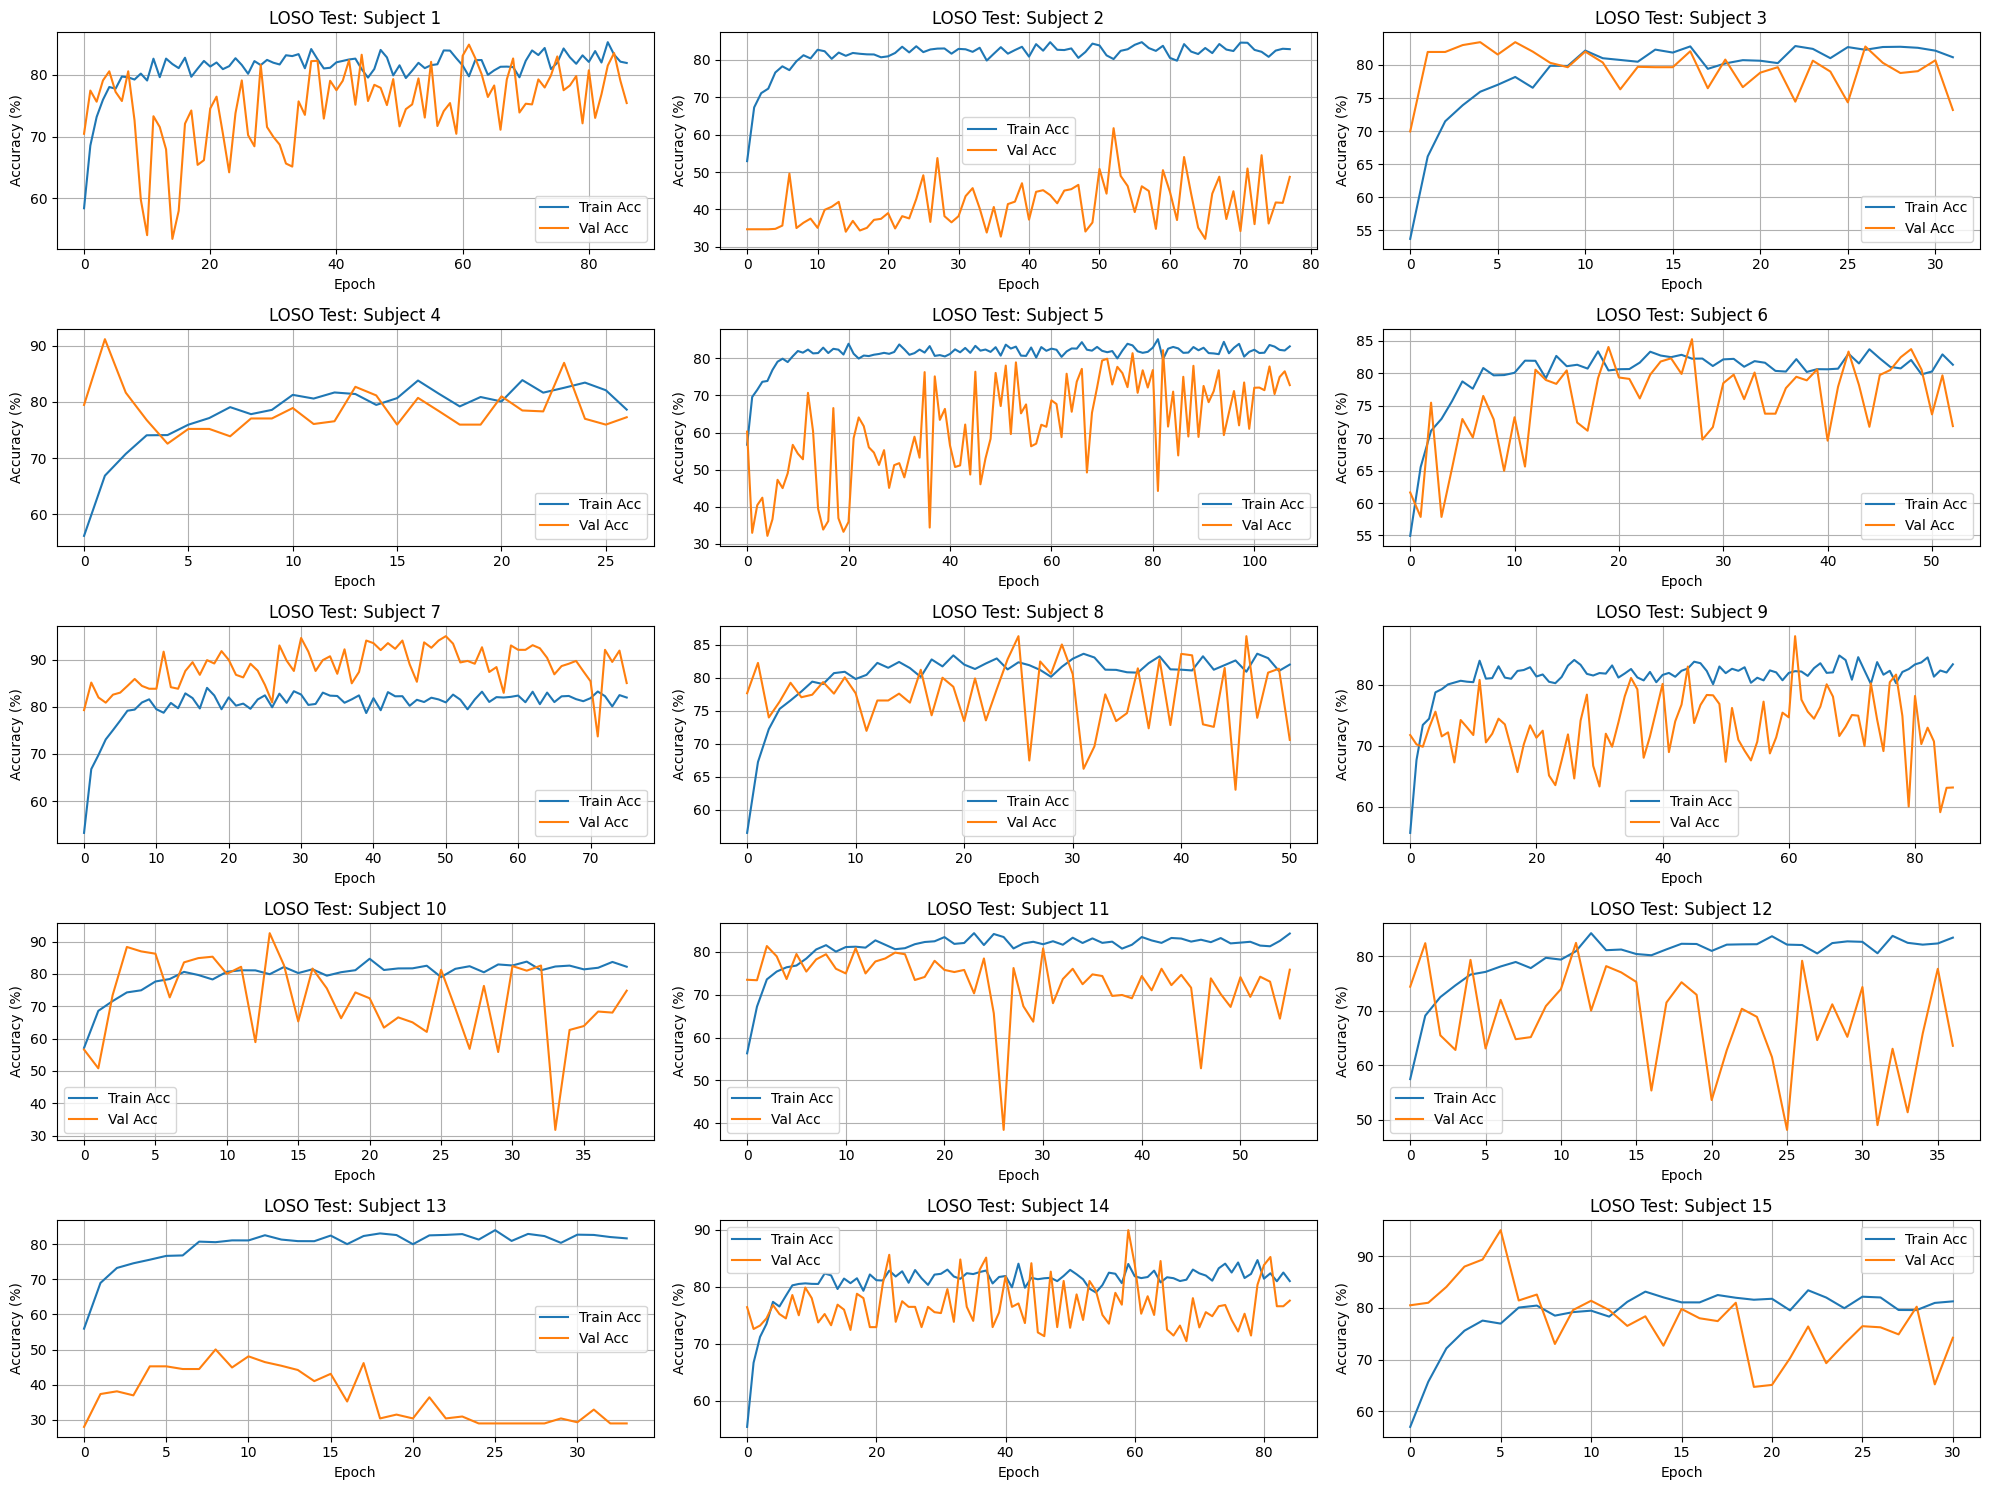

In [26]:
# --- PLOTTING ---
# 1. 5x3 Grid for individual LOSO folds
fig, axes = plt.subplots(5, 3, figsize=(20, 15))
axes = axes.flatten()

for i, subject_id in enumerate(subjects):
    if i < len(axes):
        ax = axes[i]
        if subject_id in all_subject_histories:
            h = all_subject_histories[subject_id]
            ax.plot(h["train"], label="Train Acc")
            ax.plot(h["val"], label="Val Acc")
            ax.set_title(f"LOSO Test: Subject {subject_id}")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Accuracy (%)")
            ax.legend()
            ax.grid(True)

plt.tight_layout()
plt.savefig(f"subject_accuracies {TRIAL_NUMBER}.png")
print(f"Saved subject_accuracies {TRIAL_NUMBER}.png")
# plt.show()

Saved average_accuracy 64.png


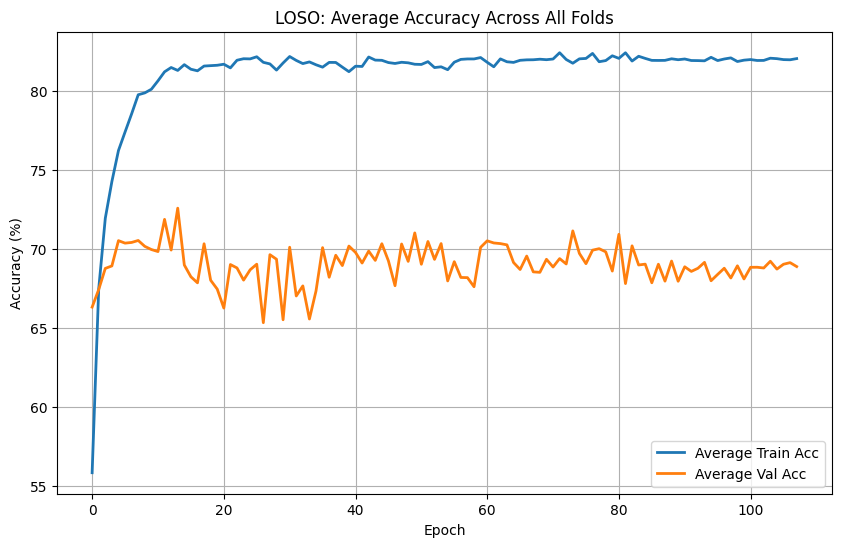

In [27]:
# 2. Average Plot
plt.figure(figsize=(10, 6))

# Find max epochs across all runs
max_epochs = 0
for h in all_subject_histories.values():
    max_epochs = max(max_epochs, len(h["train"]))

avg_train = []
avg_val = []

for e in range(max_epochs):
    t_vals = []
    v_vals = []
    for h in all_subject_histories.values():
        # Use last value if a subject finished early
        idx = min(e, len(h["train"]) - 1)
        t_vals.append(h["train"][idx])
        v_vals.append(h["val"][idx])

    avg_train.append(np.mean(t_vals))
    avg_val.append(np.mean(v_vals))

plt.plot(avg_train, label="Average Train Acc", linewidth=2)
plt.plot(avg_val, label="Average Val Acc", linewidth=2)
plt.title("LOSO: Average Accuracy Across All Folds")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.savefig(f"average_accuracy {TRIAL_NUMBER}.png")
print(f"Saved average_accuracy {TRIAL_NUMBER}.png")
# plt.show()

In [28]:
# # Concatenate all stored tensors
# all_targets = torch.cat(all_targets)
# all_predictions = torch.cat(all_predictions)
# y_true = all_targets.view(-1).cpu().numpy()
# y_pred = all_predictions.view(-1).cpu().numpy()
# cm = confusion_matrix(y_true, y_pred)
# disp = ConfusionMatrixDisplay(cm)
# disp.plot(cmap=plt.cm.Blues)
# plt.savefig(f"validation cm {TRIAL_NUMBER}.png")
